#  Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# load datsets

In [2]:
labels=pd.read_csv('labels.csv')
values=pd.read_csv('values.csv')

In [3]:
# merge datasets

In [4]:
df=pd.merge(values,labels,on="patient_id")
print(df)

    patient_id  slope_of_peak_exercise_st_segment               thal  \
0       0z64un                                  1             normal   
1       ryoo3j                                  2             normal   
2       yt1s1x                                  1             normal   
3       l2xjde                                  1  reversible_defect   
4       oyt4ek                                  3  reversible_defect   
..         ...                                ...                ...   
175     5qfar3                                  2  reversible_defect   
176     2s2b1f                                  2             normal   
177     nsd00i                                  2  reversible_defect   
178     0xw93k                                  1             normal   
179     2nx10r                                  1             normal   

     resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                       128                2                  0   
1

In [5]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [6]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [8]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [9]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [10]:
df.shape

(180, 15)

In [11]:
df.isnull().sum() # checking of the null values 

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [12]:
df["patient_id"].value_counts() # value count is it checks how many times the value appears in the data

patient_id
0z64un    1
sqddbc    1
lpub9d    1
bv01fp    1
9dqkpy    1
         ..
m2a4i9    1
pwigd8    1
qwapdq    1
4sd1xn    1
2nx10r    1
Name: count, Length: 180, dtype: int64

In [13]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [14]:
df["heart_disease_present"].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [15]:
df["sex"]=df["sex"].map({0:"Female",1:"Male"})

# EDA[Explory data analaysis]

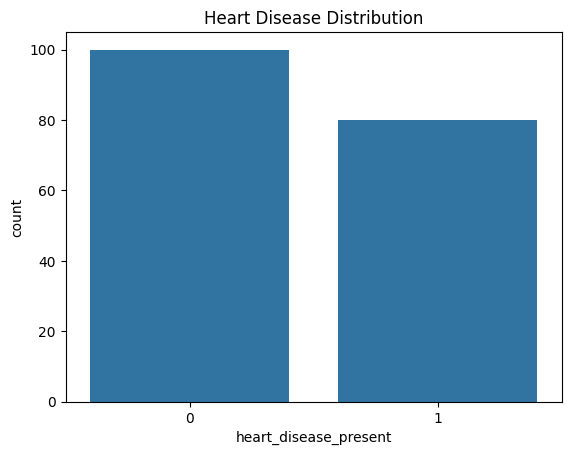

In [16]:
sns.countplot(x='heart_disease_present',data=df)
plt.title("Heart Disease Distribution")
plt.show() 

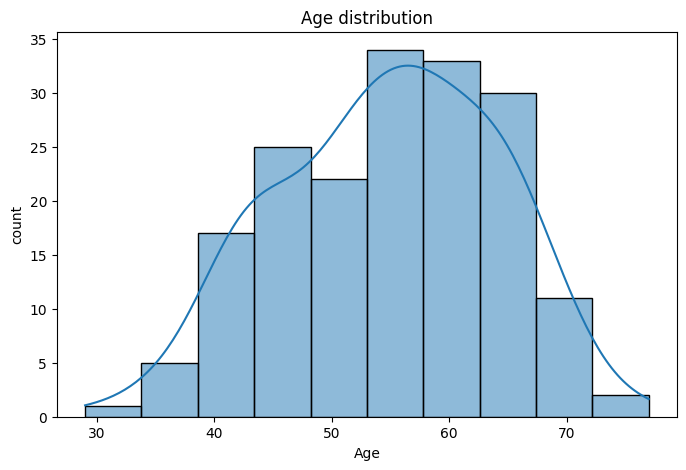

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=10,kde=True)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

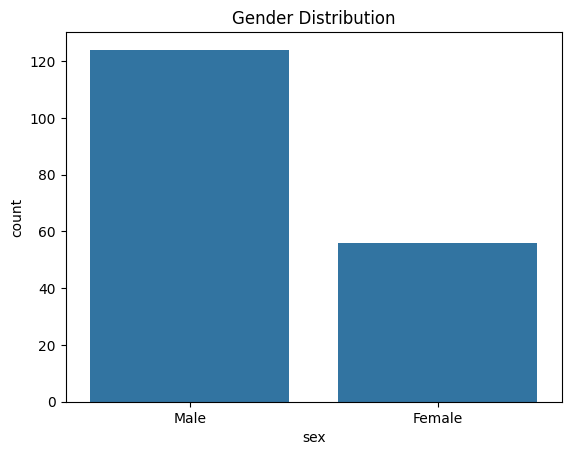

In [18]:
sns.countplot(x='sex',data=df)
plt.title("Gender Distribution")

plt.show()


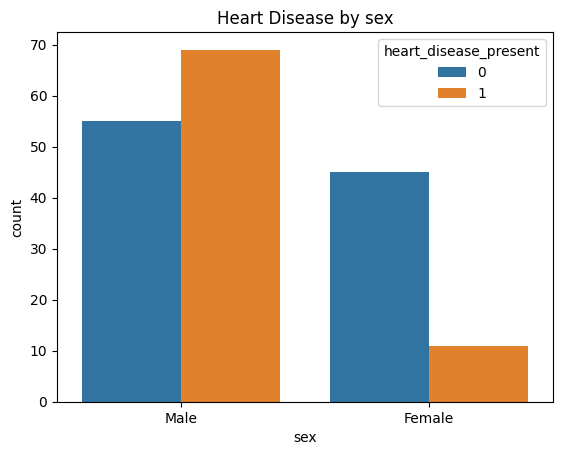

In [19]:
sns.countplot(x='sex',hue= 'heart_disease_present',data=df)
plt.title("Heart Disease by sex")
plt.show()

In [20]:
df["sex"].value_counts()

sex
Male      124
Female     56
Name: count, dtype: int64

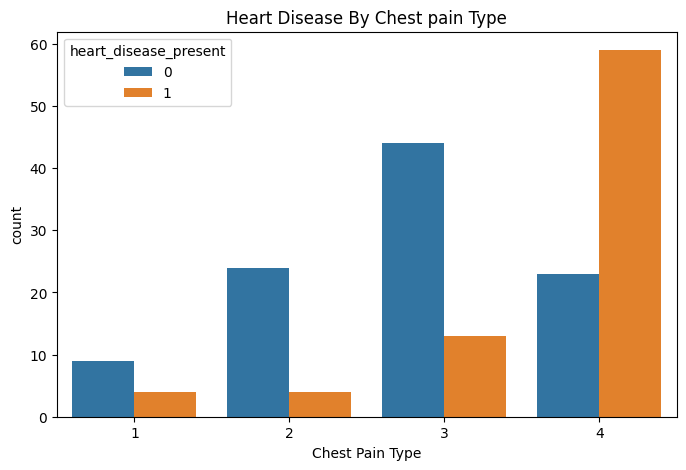

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='chest_pain_type',hue='heart_disease_present',data=df)
plt.title("Heart Disease By Chest pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("count")
plt.show()

In [22]:
# In this graph blue represents 0- no heart disease and orange represnts  1 which says heart disease is present

In [23]:
# let's analyze another feature cholestrol

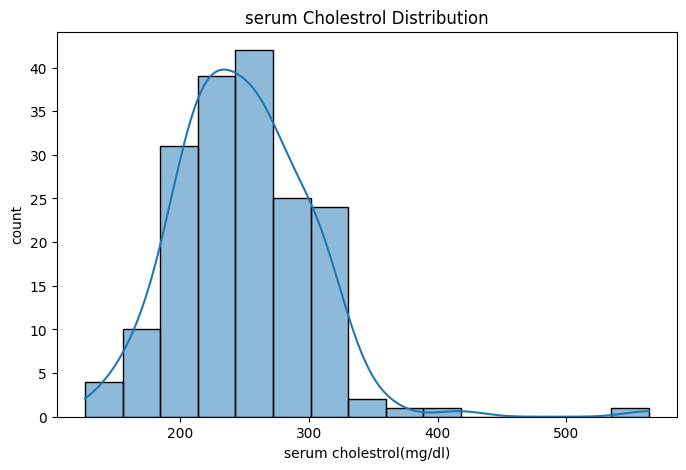

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['serum_cholesterol_mg_per_dl'],bins=15,kde=True)
plt.title("serum Cholestrol Distribution")
plt.xlabel("serum cholestrol(mg/dl)")
plt.ylabel("count")
plt.show()


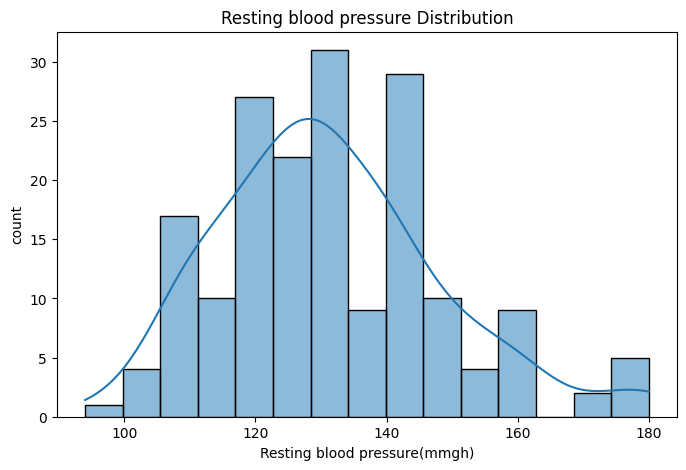

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['resting_blood_pressure'],bins=15,kde=True)
plt.title("Resting blood pressure Distribution")
plt.xlabel("Resting blood pressure(mmgh)")
plt.ylabel("count")
plt.show()

# creation of correlation heatmap

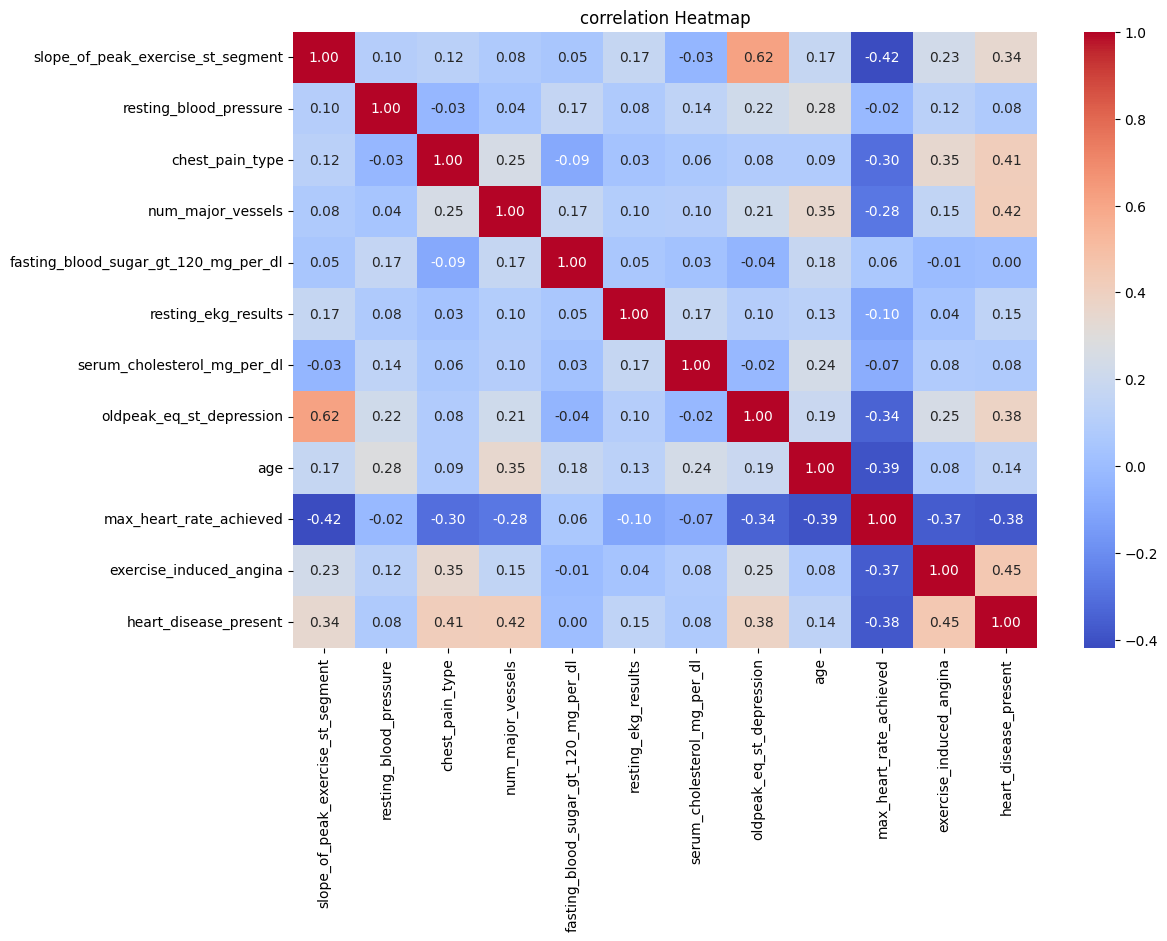

In [26]:
plt.figure(figsize=(12,8))
corr=df.drop('patient_id',axis=1).corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("correlation Heatmap")
plt.show()
                                       

In [27]:
# from the above graph by using correlation we can correlate the numerical values in the dataset present and  by observing the graph
# we can  say that Red represents the - positive correlation
# Blue represents the -Negative correlation
#White represent- No relation

# Data Preprocessing

In [28]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [29]:
df=df.drop(["patient_id"],axis=1)

In [30]:
df.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,Male,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,Female,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,Male,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,Male,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,Male,59,145,0,0


In [31]:
df['thal'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

In [32]:
#Since these are text values (object type), machine learning algorithms cannot use them directly. We need to convert them into numbers.
#we use dummies to create a dummy column which converts the categories into the numeric columns

In [33]:
df = pd.get_dummies(df,columns=["thal"], drop_first=True)

In [34]:
drop_first=True

In [35]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [36]:
print(pd)

<module 'pandas' from 'C:\\Users\\akshi\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>


In [37]:
df.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,1,128,2,0,0,2,308,0.0,Male,45,170,0,0,True,False
1,2,110,3,0,0,0,214,1.6,Female,54,158,0,0,True,False
2,1,125,4,3,0,2,304,0.0,Male,77,162,1,1,True,False
3,1,152,4,0,0,0,223,0.0,Male,40,181,0,1,False,True
4,3,178,1,0,0,2,270,4.2,Male,59,145,0,0,False,True


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    int64  
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    object 
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

In [39]:
df["sex"]=df["sex"].map({"Male":1,"Female":0}) 

In [40]:
df

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,True,False
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0,True,False
2,1,125,4,3,0,2,304,0.0,1,77,162,1,1,True,False
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1,False,True
4,3,178,1,0,0,2,270,4.2,1,59,145,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1,False,True
176,2,180,4,0,0,1,327,3.4,0,55,117,1,1,True,False
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1,False,True
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0,True,False


# Create X and Y

In [41]:
x=df.drop("heart_disease_present",axis=1)
y=df["heart_disease_present"]

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split( x,y,test_size=0.2,random_state=42,stratify=y)

In [43]:
print(x_train.shape)
print(x_test.shape)

(144, 14)
(36, 14)


In [44]:
print(df.columns)
print(df.dtypes)

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present', 'thal_normal', 'thal_reversible_defect'],
      dtype='object')
slope_of_peak_exercise_st_segment         int64
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64


In [45]:
df.isnull().sum()

slope_of_peak_exercise_st_segment       0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
thal_normal                             0
thal_reversible_defect                  0
dtype: int64

In [46]:
print(df['sex'].unique())

[1 0]


In [47]:
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [slope_of_peak_exercise_st_segment, resting_blood_pressure, chest_pain_type, num_major_vessels, fasting_blood_sugar_gt_120_mg_per_dl, resting_ekg_results, serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, sex, age, max_heart_rate_achieved, exercise_induced_angina, heart_disease_present, thal_normal, thal_reversible_defect]
Index: []


In [48]:
print(df["sex"].head())

0    1
1    0
2    1
3    1
4    1
Name: sex, dtype: int64


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    int64  
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    int64  
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [52]:
lr_pred=lr_model.predict(x_test)
print(lr_pred)

[0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1]


# Evaluating the model

In [53]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,lr_pred)
print("LogisticRegressionAccuracy:",accuracy,lr_model)

LogisticRegressionAccuracy: 0.8333333333333334 LogisticRegression(max_iter=1000)


In [54]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,lr_pred))
print(classification_report(y_test, lr_pred))

[[16  4]
 [ 2 14]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



In [55]:
# The Logistic Regression model acheived an accuracy of 83.33%,
# Which means it correctly classified approximately 83 out of every 100 patients based on the given medical features.

# Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
print(dt_pred)


[1 1 1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0]


In [57]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,dt_pred)
print("DecisionTreeAccuracy:",accuracy_score(y_test,dt_pred))


DecisionTreeAccuracy: 0.7777777777777778


In [58]:
# The Accuracy of DecisionTree model is 77%

# RandomForest

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)
print(rf_pred)

[0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1]


In [60]:
from sklearn.metrics import accuracy_score
print("RandomForestAccuracy:",accuracy_score(y_test,rf_pred))


RandomForestAccuracy: 0.8611111111111112


In [61]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,rf_pred)
print(cm)

[[16  4]
 [ 1 15]]


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



In [63]:
# The Accuracy of the RandomForest model is 86%

# knn

In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
knn_pred=knn_model.predict(x_test)
print(knn_pred)

[0 1 1 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1]


In [65]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("KNN Accuracy:",accuracy_score(y_test,knn_pred))
print(confusion_matrix(y_test,knn_pred))
print(classification_report(y_test,knn_pred))
      

KNN Accuracy: 0.8333333333333334
[[16  4]
 [ 2 14]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



In [66]:
# The  KNN model has the accuracy of 83%

# support vector machine

In [67]:
from sklearn.svm import SVC
svm_model=SVC(kernel='linear',random_state=42)
svm_model.fit(x_train,y_train)
svm_pred=svm_model.predict(x_test)
print(svm_pred)

[0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1]


In [68]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("SVC Accuracy:",accuracy_score(y_test,svm_pred))
print(confusion_matrix(y_test,svm_pred))
print(classification_report(y_test,svm_pred))

SVC Accuracy: 0.8333333333333334
[[16  4]
 [ 2 14]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



In [69]:
# The SVC accuracy is 83%

# Model comparsion Report

Five machine learning models were trained and evaluated to predict heart disease.
Their performance was compared using accuracy, confusion matrix, and classification report.

Model Performance
Model	Accuracy
Logistic Regression	83.33%
Decision Tree	77.78%
Random Forest	86.11%
K-Nearest Neighbors (KNN)	83.33%
Support Vector Machine (SVM)	83.33%
Analysis
Random Forest achieved the highest accuracy (86.11%) and produced the most reliable predictions.
Logistic Regression, KNN, and SVM each achieved 83.33% accuracy and showed good performance.
Decision Tree achieved 77.78% accuracy and showed signs of overfitting.
Best Model for Production

Based on the comparison, 
Random Forest was selected as the best model for production because it achieved the highest accuracy and provided reliable predictions. 
It is the most suitable model for heart disease prediction.

# Final conclusion

The Heart Disease Prediction Using Machine Learning project was successfully completed by developing and evaluating multiple machine learning models using patient health data. The models were compared based on evaluation metrics such as accuracy, confusion matrix, and classification report. Among all the models, Random Forest achieved the best overall performance with an accuracy of 86.11%, making it the most suitable model for predicting heart disease. After comparing the performance of all the models, Random Forest achieved the highest accuracy (86.11%) and was selected as the best model for prediction.This project demonstrates how machine learning can support the early detection of heart disease, assist healthcare professionals in decision-making, and contribute to improved patient care.

# Final Report

Project Summary:

The Heart Disease Prediction Using Machine Learning project was successfully completed using patient health data.
    The dataset was preprocessed, analyzed through Exploratory Data Analysis (EDA), and used to train multiple machine learning models, 
including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM).

Model Comparison

The models were evaluated using accuracy, confusion matrix, and classification report.

Model	Accuracy
Logistic Regression	83.33%
Decision Tree	77.78%
Random Forest	86.11%
K-Nearest Neighbors (KNN)	83.33%
Support Vector Machine (SVM)	83.33%

Among all the models, Random Forest achieved the highest accuracy (86.11%) and provided the most reliable predictions.
Therefore, it was selected as the final model for heart disease prediction.

Challenges Faced

Understanding the medical dataset and feature relationships.
Preprocessing the data by checking for missing values and duplicates.
Comparing multiple machine learning models to identify the best-performing model.
Interpreting evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrix.
Reducing overfitting by selecting Random Forest over Decision Tree.
Business Interpretation

The developed model can help healthcare professionals identify patients who are at risk of heart disease at an early stage.
Early prediction supports timely diagnosis, better treatment planning, and improved patient care.

Final Conclusion

The Heart Disease Prediction project was successfully completed by developing and evaluating multiple machine learning models. 
After comparing their performance, Random Forest was selected as the best model because it achieved the highest accuracy (86.11%)
and produced reliable predictions. 
This project demonstrates how machine learning can support the early detection of heart disease and assist healthcare professionals in making informed decisions.